# MLP NeuralODE Tutorial with Harmonic Oscillator

## Import packages
All NeuralODE models can be imported directly from `neuralode` package

In [3]:
import numpy as np
from torch import tensor
import torch.nn.functional as F
from matplotlib import pyplot as plt

from neuralode import NeuralODE, KAN_NeuralODE, Eff_KAN_NeuralODE, FastKAN_NeuralODE
from data.mass_spring_damper.loaddata import loaddata, scale, unscale

ModuleNotFoundError: No module named 'numpy'

## Test/Train Split and normalizing
Test/Train splitting can differ from type of data and examples

In [ ]:
full  = list(range(25))
test  = [0,6,12,18,24]
train = [x for x in full if x not in test]

times, inps, outs = loaddata()

metrics = [inps[train].min((0,1)), inps[train].max((0,1)), 
           outs[train].min((0,1)), outs[train].max((0,1))]

n_inps, n_outs = scale(metrics, inps, outs)

print(f"Training Input Shape = {n_inps[train].shape}, Training Output Shape = {n_outs[train].shape}")
print(f"Test Input Shape = {n_inps[test].shape}, Test Output Shape = {n_outs[test].shape}")

Training Input Shape = (20, 1000, 1), Training Output Shape = (20, 1000, 2)
Test Input Shape = (5, 1000, 1), Test Output Shape = (5, 1000, 2)


## Initialize NeuralODE Model and train
Use `NeuralODE`, `KAN_NeuralODE`, `Eff_KAN_NeuralODE` or `FastKAN_NeuralODE` to initialize a neuralode model with MLP, `KAN Efficient KAN or FastKAN. The shapes of input and output layers are built automatically by providing the data. Important here is to include a times array from which the time step size is determined.

Parameters for `NeuralODE`:
- `layers=[32,32]`: List of layers and number of neurons. Here, 2 layers with 32 neurons each.
- `hidden_activation`: Activation functions in the hidden layers. More in `torch.nn.functional`
- `out_activation`: Activation in output layer. More in `torch.nn.functional`

In [ ]:
node = NeuralODE(layers = [32,32], 
                hidden_activation = F.tanh,
                out_activation = None, 
                times = times, 
                training_inputs = tensor(n_inps[train]), 
                training_outputs = tensor(n_outs[train]), 
                test_inputs = tensor(n_inps[test]), 
                test_outputs = tensor(n_outs[test]))

MLP NeuralODE with 2 layers, [32, 32] neurons -> 1250 trainable parameters


Possibility to structure the data. For example split in multiple simulations with lower amount of time steps. 
- `batch_len`: Number of time steps per batch
- `end`: considered total number of time steps per batch 
- `batch_len` must be divisible by `end`
- Example: Data of `shape=(100, 10000, 10)` can be resorted to `new_shape=(500, 2000, 10)` by using `node.sortData(batch_len=2000, end=10000)`

In [ ]:
node.sortData(batch_len=1000, end=1000)

Training batches: 20, Test batches: 5, time steps: 1000


20

# Train method
- `cut=1000`: Use Only the first 1000 time steps per batch for training (speed up training process for initial results)
- step (higher values decrease training times, but may also decrease accuracy depending on solver and the dynamics of the problme)
    - If `step=1`, all time steps are used
    - If `step=2`, every second time step (skip one between each)
    - `step=k` means every k-th time step
- `solver`: Solvers to use for the integration of the ODE. `"euler"`, `"rk4"`, `"dopri5"`, ... (see torchdiffeq for more solvers; adaptive time step solvers to be implemented)
- `set_optimizer`: Optimizer for minimization of the loss and update of the trainable parameters.
    - `"adam"` (default): All rounder, may converge slower, better for high dimensional, non-physical data
    - `"lbfgs"`: Increased training time, multiple evaluations per gradient update
- `lr`: Learning rate for the optimizer. 
    - Choose `lr=0.001` as initial learning rate for `"adam"` and decrease by factor of 0.5 or 0.1, if loss reaches plateau.
    - Choose `lr=1` as initial learning rate for `"lbfgs"` and decrease by factor of 0.5, if loss reaches plateau.
- `epochs`: Number of epochs = Number of total iterations of entire data set
- `batch_size=32` (default): Number of training examples for one parameter update
- `plot_loss=True` (default): Plots loss and validation loss


 Training started with 20 training batches, and 1000 time steps.
Epoch: 1/10, loss: 3.50752, val loss: 0.007615, 6.577s/epoch
Epoch: 2/10, loss: 0.013874, val loss: 0.005331, 6.498s/epoch
Epoch: 3/10, loss: 0.006791, val loss: 0.000365, 6.188s/epoch
Epoch: 4/10, loss: 0.000991, val loss: 3e-05, 6.008s/epoch
Epoch: 5/10, loss: 3.7e-05, val loss: 1e-05, 6.0s/epoch
Epoch: 6/10, loss: 1.7e-05, val loss: 5e-06, 5.999s/epoch
Epoch: 7/10, loss: 6e-06, val loss: 3e-06, 5.901s/epoch
Epoch: 8/10, loss: 5e-06, val loss: 3e-06, 0.942s/epoch
Epoch: 9/10, loss: 5e-06, val loss: 3e-06, 0.913s/epoch
Epoch: 10/10, loss: 5e-06, val loss: 3e-06, 0.893s/epoch
Final loss: 5e-06, training duration for 10 epochs: 46.9 seconds


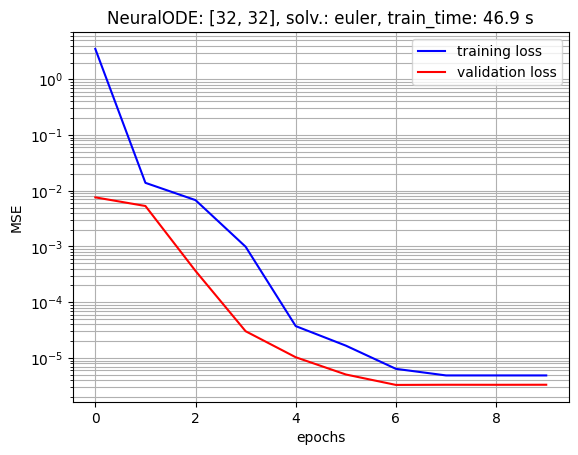

Prediction time for 1000 time steps: 0.1 seconds


In [9]:
node.train(cut = 1000,
        step = 1,
        solver = 'euler',
        set_optimizer = 'lbfgs',
        lr = 1,
        epochs = 10,
        batch_size=32)

pred = unscale(metrics, node.predict(times=times, inps=tensor(n_inps), init=tensor(n_outs[:,0,:]), solver='euler' ,print_time=True))


# Define Plot function

In [10]:
def plot(no, times, inps, outs, pred):
    plt.figure(no)
    plt.plot(times, inps[no], c='black', label='input')
    plt.plot(times, outs[no,:,0], '--', c='tab:cyan', label='x true')
    plt.plot(times, pred[no,:,0], c='tab:blue', label='x pred')
    plt.plot(times, outs[no,:,1], '--', c='tab:orange', label=r'$\dot{x}$ true')
    plt.plot(times, pred[no,:,1], c='tab:red', label=r"$\dot{x}$ pred")
    plt.title(f'KAN/NeuralODE - Harmonic Oscillator - Test Set {no}'); plt.legend(); plt.xlabel('t in s'); plt.ylabel(r'x, $\dot{x}$')
    plt.grid()


Plotting test and train results

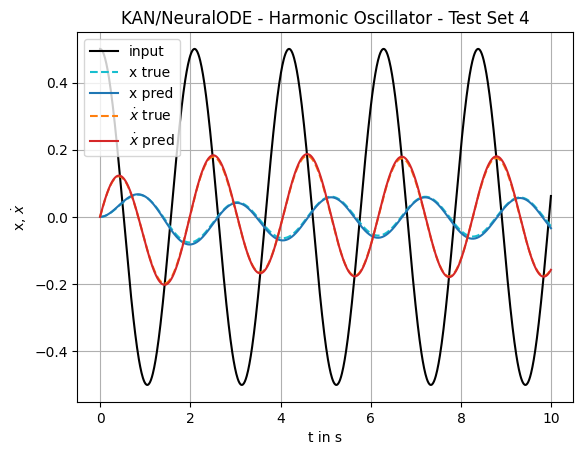

In [11]:
plot(4, times, inps, outs, pred)